# T03 · Magnetic MACE — spin-conditioned energy

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Neutrino155/MACE_tutorials/blob/main/MACE_extensions/T03-MagneticMACE.ipynb)

**Lennard-Jones Centre · University of Cambridge · Atomic-Scale Modelling**

Inspect a spin-conditioned energy model, then scan an Fe₂ teaching dimer over bond length and relative moment alignment.

**Route:** architecture in [T00](T00-Extending-MACE.ipynb); training foundations in [Practice I](../MACE_in_practice_I/T01-MACE-Practice-I.ipynb) and [Practice II](../MACE_in_practice_II/T02-MACE-Practice-II.ipynb); optional theory in [MACE Theory](../MACE_advanced/T03-MACE-Theory.ipynb).

## Setup

Run the setup and import cells in order. Local Jupyter needs a compatible magnetic MACE-Field checkout (`MACEFIELD_ROOT`); Colab fetches the documented magnetic source revision and dependencies. See the [extension guide](README.md).

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
_original_showwarning = warnings.showwarning

def _quiet_user_and_deprecation_warnings(message, category, filename, lineno,
                                         file=None, line=None):
    if issubclass(category, (UserWarning, DeprecationWarning)):
        return
    _original_showwarning(message, category, filename, lineno, file=file, line=line)

warnings.showwarning = _quiet_user_and_deprecation_warnings

import importlib.util
import subprocess
import sys
from pathlib import Path

try:
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except (ImportError, ValueError):
    IN_COLAB = False
if IN_COLAB:
    TUTORIAL_ROOT = Path("/content/MACE_tutorials")
    if not (TUTORIAL_ROOT / "MACE_extensions").is_dir():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", "main",
             "https://github.com/Neutrino155/MACE_tutorials.git", str(TUTORIAL_ROOT)],
            check=True,
        )
else:
    TUTORIAL_ROOT = next(
        (root for root in (Path.cwd(), *Path.cwd().parents)
         if (root / "MACE_extensions").is_dir()),
        None,
    )
    if TUTORIAL_ROOT is None:
        raise FileNotFoundError("Open this notebook from the MACE_tutorials repository.")

sys.path.insert(0, str(TUTORIAL_ROOT))
from MACE_extensions.scripts.notebook_setup import setup

SETUP = setup(feature="magnetic")
from MACE_extensions.scripts.bootstrap import ensure as ensure_dependencies
ensure_dependencies("magnetic")
ASSET_ROOT = Path(SETUP["asset_root"])
REPO = Path(SETUP["source_root"])


MACE-Field source: /home/brad/repositories/mace-field-develop · Colab: False
CUDA NVRTC libraries prepared from: /home/brad/miniconda3/envs/mace-field/lib/python3.14/site-packages/nvidia/cu13/lib
Dependencies ready for: magnetic


In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import inspect
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from ase import Atoms
from ase.io import read
from IPython.display import display
from mace.calculators import MACECalculator
from mace.modules.extensions import MACEField, MACELES
from mace.modules.models import AtomicDipolesMACE

from MACE_extensions.scripts.notebook_tools import read_source, show_source_hits
import importlib

structure_viewer = importlib.import_module("MACE_extensions.scripts.structure_viewer")
importlib.reload(structure_viewer)
animate_structures = structure_viewer.animate_structures
show_structure = structure_viewer.show_structure
show_structure_gallery = structure_viewer.show_structure_gallery

DEVICE = os.environ.get(
    "MACE_TUTORIAL_DEVICE",
    "cuda" if torch.cuda.is_available() else "cpu",
)
MODEL_DTYPE = "float64"
MODEL_PATHS = {
    "dipole": Path(SETUP["dipoles_model"]),
    "magnetic": Path(SETUP["magnetic_model"]),
    "les": Path(SETUP["les_model"]),
    "short_range": Path(SETUP["les_local_control"]),
}
if "macefield_model" in SETUP:
    MODEL_PATHS["field"] = Path(SETUP["macefield_model"])

def require_model(name):
    path = Path(MODEL_PATHS[name])
    if not path.is_file():
        raise FileNotFoundError(f"Model file not found: {path}")
    return path

print(f"Source: {REPO} · {'Colab' if IN_COLAB else 'local Jupyter'} · {DEVICE}")

# Reapply after imports because some scientific packages reset warning filters.
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.showwarning = _quiet_user_and_deprecation_warnings


Source: /home/brad/repositories/mace-field-develop · local Jupyter · cpu


In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from mace.calculators import MagneticMACECalculator
from mace.modules.extensions import MagneticScaleShiftMACE, MagneticSCFMACE
from scipy.spatial.transform import Rotation

# Reapply after imports because some scientific packages reset warning filters.
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.showwarning = _quiet_user_and_deprecation_warnings


### Inspect example structures

Choose a teaching set from the menu, then rotate and zoom to inspect its geometry and available overlays.

In [4]:
DATA_CHOICES = {
    "BaTiO₃ soft-mode training data": "macefield_batio3_toy_train.extxyz",
    "Water dipole training data": "atomicdipoles_water_train.extxyz",
    "Fe₂ magnetic training data": "magnetic_fe2_train.extxyz",
    "Water dimer LES training data": "maceles_water_dimer_train.extxyz",
}

example_structures = {
    name: read(ASSET_ROOT / "data" / filename, index=0)
    for name, filename in DATA_CHOICES.items()
}
display(show_structure_gallery(
    example_structures,
    title="Inspect the teaching structures",
    default_choice='Fe₂ magnetic training data',
))


<IPython.core.display.Javascript object>

## Extension 3 — Magnetic MACE: condition energy on moments

### 3.1 Architecture change

The target is a scalar energy $E(\mathbf R,\mathbf m)$: identical geometries can have different energies for different site moments. `MagneticScaleShiftMACE` builds radial features from moment magnitudes and angular features from moment directions, then supplies them to magnetic-aware interaction and product blocks. The output remains an energy; forces and magnetic forces are derivatives at fixed inputs. `MagneticSCFMACE` is a separate wrapper that relaxes moments.

#### Magnetic features in the architecture

Moment magnitude and orientation features enter the message-passing stack before the energy readout. The magnetic force is $-\partial E/\partial\mathbf m_i$ at fixed positions.

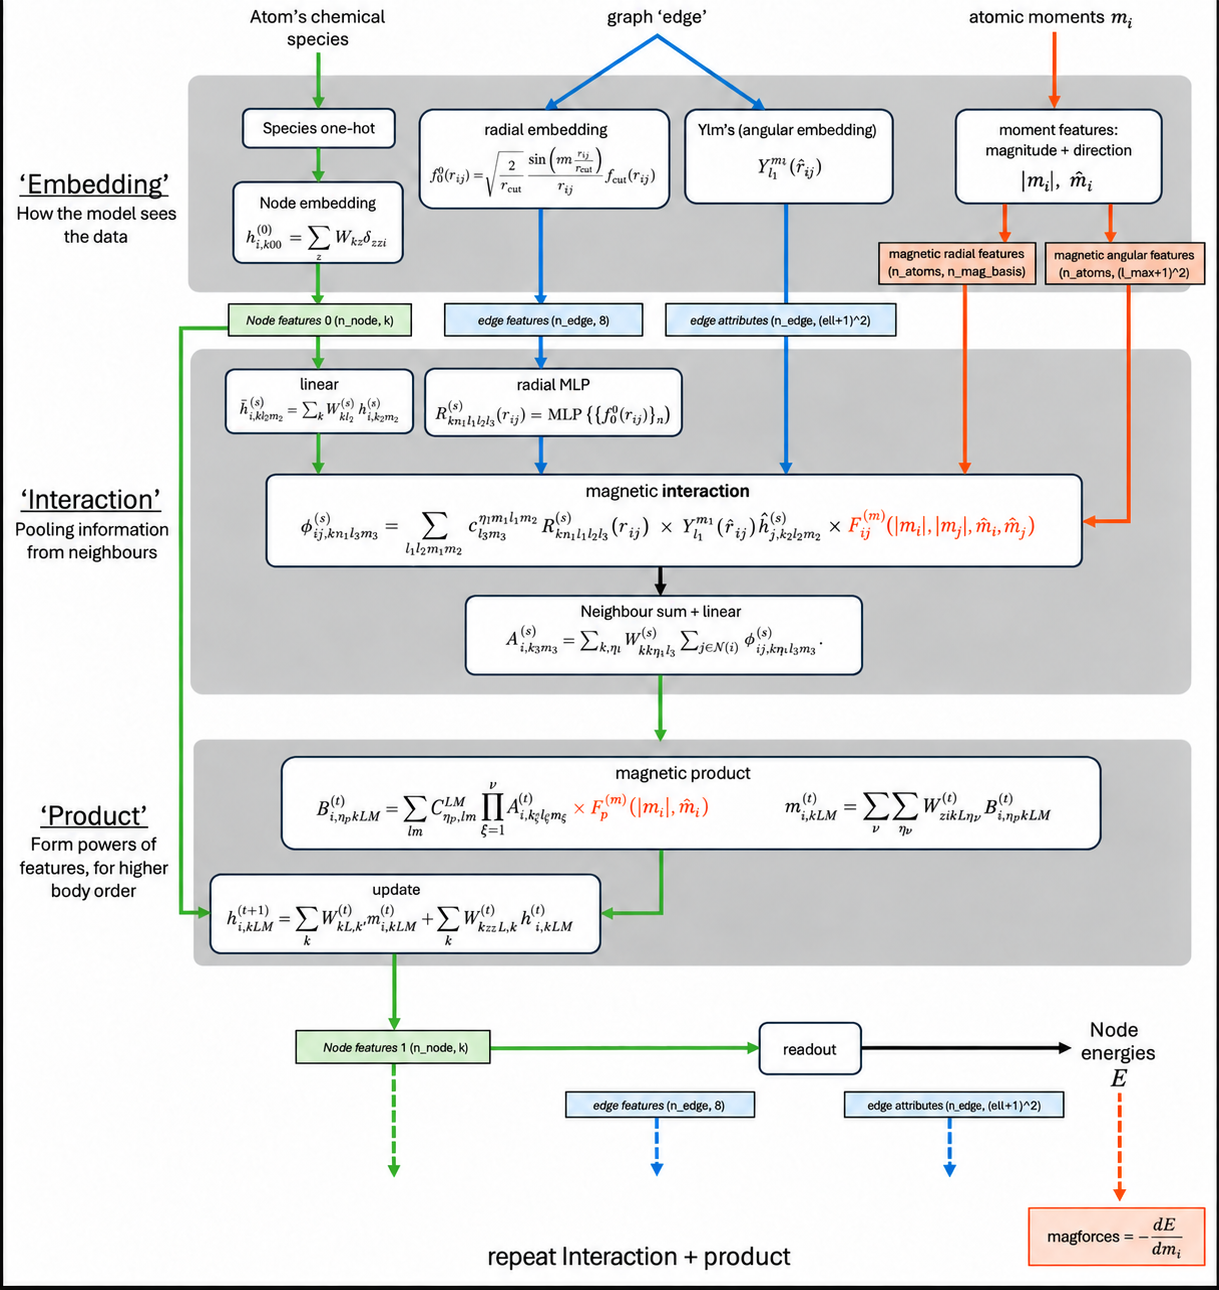

### 3.2 Physical constraints

Declare the moment unit and convention in the data schema.

<details>
<summary><b>Background theory: magnetic symmetry and derivatives</b></summary>

- **State variables:** atomic positions R and magnetic moments m are separate variables. Record moment units (commonly μB), magnitude bounds, and the moment convention in the data schema.
- **Spatial transformation:** under a rigid rotation, positions and moments must be transformed consistently. Magnetic moment is physically an axial vector under inversion; check the exact parity/SO(3) convention implemented by the chosen block.
- **Time reversal:** for a nonmagnetic environment without a time-reversal-breaking field, simultaneous reversal of all moments should leave a time-reversal-even energy unchanged. Spin–orbit and external-field conventions need explicit treatment.
- **Forces:** Fᵢ = −∂E/∂Rᵢ at fixed moments.
- **Magnetic forces:** fᵢᵐ = −∂E/∂mᵢ, in energy per moment unit.
- **Fixed versus relaxed moments:** if a wrapper solves m*(R), the derivative of E(R,m*(R)) includes the relaxation response. Do not label a fixed-moment derivative as the fully relaxed derivative.
</details>

### 3.3 Follow the implementation

Inspect `MagneticScaleShiftMACE` in `mace/modules/extensions.py`: trace moment embeddings, magnetic irreps and derivative outputs.

In [5]:
show_source_hits(
    MagneticScaleShiftMACE.__init__,
    needles=("super().__init__", "atomic_inter_scale", "atomic_inter_shift"),
    context=5,
)
show_source_hits(
    MagneticScaleShiftMACE.forward,
    needles=("magmom", "magforces", "get_outputs", '"energy"'),
    context=7,
    max_chars=10000,
)
read_source("mace/modules/extensions.py", 1910, 2055, root=REPO)

2189 2190 2191 2192 2193 2194 2195 2196 2197 2198 2199 2200 2201 2202 2203,"def __init__( self, atomic_inter_scale: float, atomic_inter_shift: float, **kwargs, ): num_mag_radial_basis_one_body = kwargs.pop(""num_mag_radial_basis_one_body"", 0) super().__init__(**kwargs) self.scale_shift = ScaleShiftBlock( scale=atomic_inter_scale, shift=atomic_inter_shift ) if self.use_magmom_one_body: # coefficient for the chebyshev polynomails self.onebody_magmombasis_coeffs = torch.nn.Parameter("


#### Source-reading task

Find where moments are scaled and passed to the blocks. Which option controls the one-body magnetic contribution, and how might predictions behave outside the training moment range?

### 3.4 Data and training

Each ExtXYZ frame should contain per-site moment vectors plus reference energies and forces; magnetic-force labels are optional. Keep units and conventions consistent.

**Pretraining:** `bash MACE_extensions/scripts/train_magnetic.sh`

- Training: `MACE_extensions/data/magnetic_fe2_train.extxyz`
- Validation: `MACE_extensions/data/magnetic_fe2_valid.extxyz`
- Defaults: CPU, 100 epochs; set `DEVICE=cuda` or `EPOCHS=...` to change them.
- Output: `MACE_extensions/models/magnetic/`.

In [6]:
MAGNETIC_TRAINING_OPTIONS = {
    "model": "MagneticScaleShiftMACE",
    "loss": "universal",
    "hidden_irreps": "32x0e",
    "compute_magforces": True,
    "interaction_first": "MagneticRealAgnosticSpinOrbitCoupledDensityInteractionBlock",
    "interaction": "MagneticRealAgnosticSpinOrbitCoupledDensityInteractionBlock",
    "magmom_key": "REF_magmom",
    "magforces_key": "REF_magforces",
    "magforces_weight": 5.0,
    "m_max": 4.0,                  # set from the data's supported moment range
    "num_mag_radial_basis": 8,
    "max_m_ell": 1,
}
MAGNETIC_TRAINING_OPTIONS

{'model': 'MagneticScaleShiftMACE',
 'loss': 'universal',
 'hidden_irreps': '32x0e',
 'compute_magforces': True,
 'interaction_first': 'MagneticRealAgnosticSpinOrbitCoupledDensityInteractionBlock',
 'interaction': 'MagneticRealAgnosticSpinOrbitCoupledDensityInteractionBlock',
 'magmom_key': 'REF_magmom',
 'magforces_key': 'REF_magforces',
 'magforces_weight': 5.0,
 'm_max': 4.0,
 'num_mag_radial_basis': 8,
 'max_m_ell': 1}

The bundled Fe₂ labels are analytic teaching targets. The training cell below shows the model-specific options used by the pretraining script.

In [7]:
read_source("tests/extensions/magnetic/test_magmace.py", 20, 105, root=REPO)

20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104


> **Inspect the data:** load a magnetic ExtXYZ file and check that `REF_magmom` has shape `(N, 3)` in every frame. Plot moment magnitude against species. Check that labels cover ferromagnetic, antiferromagnetic, non-collinear and low-moment states relevant to your intended use. Compare training and test structures after symmetry-aware matching.

### 3.5 Construct and view an Fe dimer spin series

The probe holds an Fe–Fe distance fixed while changing the relative moment angle from parallel to antiparallel. This isolates one magnetic coordinate. The structure viewer draws moment vectors on both sites.

In [8]:
def fe_dimer(distance=2.4, angle_degrees=0.0, moment=2.2, box=12.0):
    theta = np.deg2rad(angle_degrees)
    atoms = Atoms("Fe2", positions=[[5.0 - distance / 2, 6.0, 6.0],
                                    [5.0 + distance / 2, 6.0, 6.0]],
                  cell=[box, box, box], pbc=False)
    moments = np.array([[0.0, 0.0, moment],
                        [moment * np.sin(theta), 0.0, moment * np.cos(theta)]])
    atoms.new_array("magmom", moments)
    return atoms

probe = fe_dimer(distance=2.4, angle_degrees=90.0)
spin_vectors = [(probe.positions[i], probe.arrays["magmom"][i], f"m{i}", "#16805d", "μB")
                for i in range(2)]
display(show_structure(probe, vectors=spin_vectors, title="Fe dimer with 90° relative moment angle"))

<IPython.core.display.Javascript object>

In [9]:
spin_angles_to_view = np.linspace(0.0, 180.0, 37)
spin_angle_states = [
    fe_dimer(distance=2.4, angle_degrees=float(angle))
    for angle in spin_angles_to_view
]
spin_vectors_by_frame = [
    [
        (atoms.positions[index], atoms.arrays["magmom"][index], f"m{index}", "#16805d", "μB")
        for index in range(2)
    ]
    for atoms in spin_angle_states
]
display(animate_structures(
    spin_angle_states,
    title="Fe₂ spin alignment · fixed 2.4 Å separation",
    frame_labels=[f"Relative spin angle = {angle:.0f}°" for angle in spin_angles_to_view],
    vectors_by_frame=spin_vectors_by_frame,
    show_cell=False,
    height=450,
    play_speed=260,
))


<IPython.core.display.Javascript object>

### 3.6 Checkpoint demonstration: map E(distance, relative spin angle)

Set a magnetic checkpoint trained for Fe and with a compatible cutoff, magnetic input key, and moment convention. This uses <code>MagneticMACECalculator</code>, the repository's magnetic ASE calculator. Energies below are shifted by a common reference value to make the spin-state splitting visible; do not infer absolute formation energies from this plot.

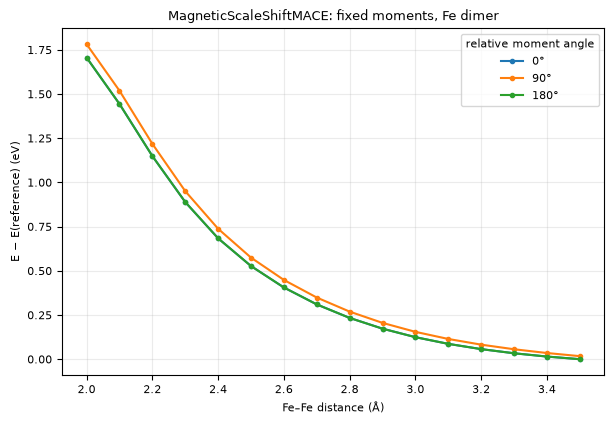

In [10]:
mag_calc = MagneticMACECalculator(
    model_paths=str(require_model("magnetic")),
    device=DEVICE, default_dtype=MODEL_DTYPE,
    magmom_key="magmom",
)
spin_angles = [0.0, 90.0, 180.0]
distances = np.linspace(2.0, 3.5, 16)
energy_curves = {}
for angle in spin_angles:
    values = []
    for distance in distances:
        atoms = fe_dimer(distance=distance, angle_degrees=angle)
        atoms.calc = mag_calc
        values.append(atoms.get_potential_energy())
    energy_curves[angle] = np.asarray(values)
reference = energy_curves[0.0][-1]

fig, ax = plt.subplots(figsize=(7, 4.5))
for angle, energies in energy_curves.items():
    ax.plot(distances, energies - reference, marker="o", ms=3, label=f"{angle:.0f}°")
ax.set(xlabel="Fe–Fe distance (Å)", ylabel="E − E(reference) (eV)",
       title="MagneticScaleShiftMACE: fixed moments, Fe dimer")
ax.legend(title="relative moment angle")
ax.grid(alpha=0.25)
plt.show()

#### Interpret the scan carefully

The curves show what the trained model predicts for this *probe family*. A physical conclusion needs matched reference calculations, coverage of the tested moment/distance range, a consistent magnetic state definition, and uncertainty checks. If all curves overlap exactly, first check that moment arrays reach the calculator under the expected key and that the chosen checkpoint is a magnetic model.

#### Model-level rotation test

Rotate the dimer geometry and both moment vectors together. This is a useful check for a scalar-energy magnetic model. If using a spin–orbit-coupled checkpoint, rotate the crystal/environment and moments consistently; do not rotate the moments alone.

In [11]:
atoms = fe_dimer(distance=2.4, angle_degrees=65.0)
atoms.calc = mag_calc
energy_original = atoms.get_potential_energy()
Q = Rotation.from_euler("xyz", [25.0, 40.0, 12.0], degrees=True).as_matrix()
rotated = atoms.copy()
rotated.positions = atoms.positions @ Q.T
rotated.arrays["magmom"] = atoms.arrays["magmom"] @ Q.T
rotated.calc = mag_calc
energy_rotated = rotated.get_potential_energy()
print("rotation energy residual (eV):", abs(energy_rotated - energy_original))

rotation energy residual (eV): 0.0


<details>
<summary><b>Background theory: fixed and relaxed moments</b></summary>

This scan holds m fixed. <code>MagneticSCFMACE</code> instead wraps a magnetic model with an iterative magnetic-moment update, caches converged moments in some workflows, and changes the derivative question. Read its forward and calculator paths before describing a relaxed magnetic force. An unrolled iteration, an implicit stationary derivative, and a fixed-input derivative are three different objects.
</details>

## Continue

Compare this design in [T00 — Extending MACE](T00-Extending-MACE.ipynb). For training, see [Practice I](../MACE_in_practice_I/T01-MACE-Practice-I.ipynb) and [Practice II](../MACE_in_practice_II/T02-MACE-Practice-II.ipynb); for architecture, see [MACE Theory](../MACE_advanced/T03-MACE-Theory.ipynb). Source revisions, example-data limits and acknowledgements are in the [extension guide](README.md).